# Task 3: Unsupervised Learning

## Research Question

> **What natural groupings (clusters) exist within Vinh Tuy Bridge traffic patterns, and do these clusters correspond to identifiable real-world traffic scenarios?**

Unlike supervised learning, we do not use the label `is_congested` to guide the algorithm. Instead, K-Means clustering discovers structure in the feature space independently, allowing us to verify whether the data naturally organises into interpretable traffic contexts (e.g., inbound rush-hour, off-peak outbound, weekend patterns).

## Methodology
1. Load the processed dataset.
2. Standardize features using MinMax scaling (preserves binary/ordinal structures).
3. Find optimal K using the Elbow Method + Silhouette Score.
4. Fit the final K-Means model on all 6 features (not PCA-reduced).
5. Use PCA and t-SNE **only for 2D visualization** of the clusters.
6. Profile each cluster to interpret real-world traffic scenarios.

## Section 1: Imports & Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import os

# Configuration & Setup
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
OPTIMAL_K = 4

# Ensure output directory for visualization exists
output_dir = os.path.join("..", "..", "Data Visualization", "Task 3")
os.makedirs(output_dir, exist_ok=True)


## Section 2: Load Datasets

We load the dataset and select the 6 core features.

**Why exclude `is_congested` from clustering?**
Clustering is an **unsupervised** technique, it must discover structure from features alone, without being guided by the target label. Including `is_congested` would bias the clusters toward a pre-known separation and defeat the purpose of exploring hidden patterns.

In [2]:
# Load Data
file_path = os.path.join("Processed Datasets", "Processed Dataset.csv")
if not os.path.exists(file_path):
    file_path = os.path.join("..", "..", "Datasets", "Processed Dataset.csv")

df = pd.read_csv(file_path)

# The 6 core features
features = [
    'is_rush_hour', 'direction_inbound', 'adverse_weather_score',
    'rush_weather_interaction', 'dow_sin', 'dow_cos'
]
target = 'is_congested'

missing_columns = sorted(set(features + [target]) - set(df.columns))
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

X = df[features]

print(f'Dataset shape: {X.shape}')


Dataset shape: (6587, 6)


## Section 3: Feature Scaling

**Why MinMax Scale Before K-Means?**

K-Means assigns each point to its nearest centroid using **Euclidean distance**. If features are on very different scales, those with larger numerical ranges dominate the distance calculation.

`MinMaxScaler` transforms each feature to a bounded interval. This is chosen here because it preserves the binary/ordinal structure of our engineered features (like `is_rush_hour` and `adverse_weather_score`), giving K-Means a cleaner separation of traffic states on bounded intervals.

In [3]:
scaler = MinMaxScaler()
X_processed = scaler.fit_transform(X)

print(f"Original dataset shape: {X_processed.shape}")
print(f"Feature minimums after scaling: {X_processed.min(axis=0).round(4)}")
print(f"Feature maximums after scaling: {X_processed.max(axis=0).round(4)}")


Original dataset shape: (6587, 6)
Feature minimums after scaling: [0. 0. 0. 0. 0. 0.]
Feature maximums after scaling: [1. 1. 1. 1. 1. 1.]


## Section 4: Optimal K Selection - Elbow Method + Silhouette Score

Choosing the right number of clusters K is crucial. We use two complementary methods:

**Elbow Method (Inertia / WCSS):**
Inertia is the sum of squared distances from each point to its assigned centroid. It decreases as K increases. We look for the **"elbow"** - the K value where the rate of decrease suddenly slows.

**Silhouette Score:**
For each point, the silhouette score measures how similar it is to its own cluster versus the nearest neighbouring cluster. A **peak** in silhouette score indicates the most cohesive and separated clustering.

Based on our evaluation on the full 6D dataset, **$K=4$** was selected as the optimal number of clusters.



--- STEP 1: Running Elbow Method and Silhouette Analysis on 6D data ---



K-Means evaluation by K:
 K   Inertia  Silhouette Score
 2 3875.1234            0.3054
 3 2961.6238            0.3230
 4 2228.3957            0.4132
 5 2016.5686            0.3801
 6 1804.8377            0.3729
 7 1634.7273            0.3730
 8 1466.9575            0.3771
 9 1332.5089            0.3942
10 1204.6912            0.4095


Saved Optimal K plot to: 5_elbow_silhouette.png


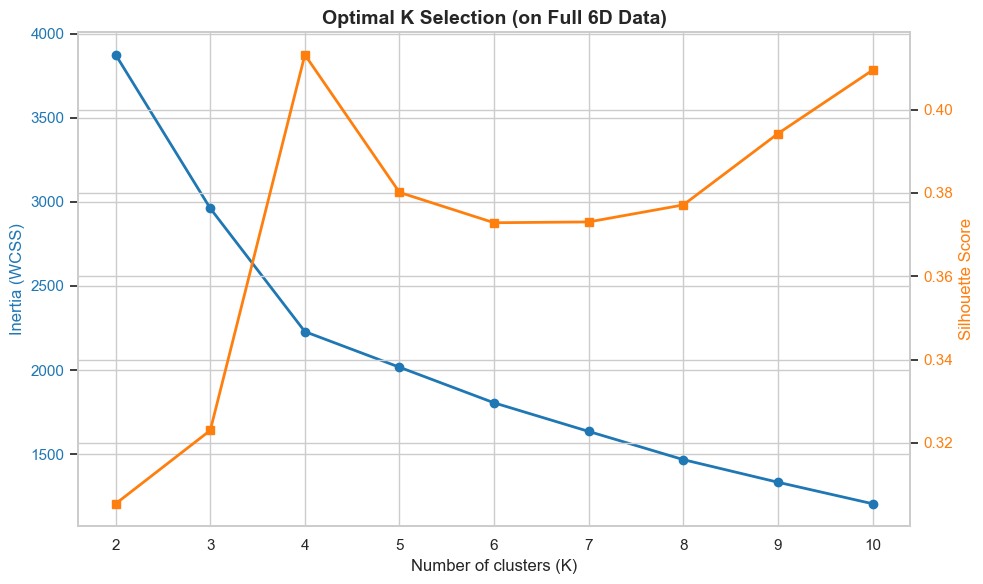

In [4]:
print("\n--- STEP 1: Running Elbow Method and Silhouette Analysis on 6D data ---")
K_range = range(2, 11)
evaluation_rows = []
selected_model = None
selected_labels = None
selected_silhouette = None

for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = km.fit_predict(X_processed)
    silhouette = silhouette_score(X_processed, labels)

    evaluation_rows.append({
        "K": k,
        "Inertia": km.inertia_,
        "Silhouette Score": silhouette,
    })

    if k == OPTIMAL_K:
        selected_model = km
        selected_labels = labels
        selected_silhouette = silhouette

if selected_model is None:
    raise ValueError(f"OPTIMAL_K={OPTIMAL_K} was not evaluated in K_range.")

k_evaluation = pd.DataFrame(evaluation_rows)
print("\nK-Means evaluation by K:")
print(k_evaluation.round(4).to_string(index=False))

# Plotting the evaluation metrics
fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:blue'
ax1.set_xlabel('Number of clusters (K)', fontsize=12)
ax1.set_ylabel('Inertia (WCSS)', color=color, fontsize=12)
ax1.plot(k_evaluation["K"], k_evaluation["Inertia"], marker='o', color=color, linewidth=2, label='Inertia (Elbow)')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = 'tab:orange'
ax2.set_ylabel('Silhouette Score', color=color, fontsize=12)  
ax2.plot(k_evaluation["K"], k_evaluation["Silhouette Score"], marker='s', color=color, linewidth=2, label='Silhouette Score')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Optimal K Selection (on Full 6D Data)', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.savefig(os.path.join(output_dir, "5_elbow_silhouette.png"), dpi=300)
print("Saved Optimal K plot to: 5_elbow_silhouette.png")
plt.show()


## Section 5: Final K-Means Model

We apply the final model using $K=4$, which was selected based on our evaluation.

**Justification:**
- **Silhouette Score:** The silhouette curve shows a distinct, prominent peak precisely at $K=4$ (score $> 0.41$). This indicates that 4 clusters provide the most cohesive and well-separated grouping of the traffic data compared to any other value of K.
- **Inertia (Elbow Method):** The WCSS (inertia) curve shows a sharp, steep decline from $K=2$ to $K=4$. After $K=4$, the rate of decrease noticeably flattens out, forming the "elbow." The combination of the highest silhouette score and the elbow at $K=4$ makes it the mathematical optimum.
- **Real-World Interpretation:** $K=4$ perfectly captures the highest-level operational states of the bridge: it cleanly splits the dataset into **Rush Hour** (further subdivided by clear vs. adverse weather) and **Off-Peak** traffic (further subdivided by inbound vs. outbound direction).

**`n_init=20`:** Runs K-Means 20 times with different random centroid initializations and keeps the best result (lowest inertia). This avoids poor local minima, which K-Means is highly susceptible to due to its random initialization.

**`random_state=42`:** Ensures reproducibility of the best result across multiple runs so that our cluster definitions remain stable.

In [5]:
print(f"\n--- STEP 2: Using Final K-Means Model with K={OPTIMAL_K} ---")

df['Cluster'] = selected_labels

print(f"Final Model Inertia (Loss): {selected_model.inertia_:.2f}")
print(f"Final Model Silhouette Score: {selected_silhouette:.4f}")



--- STEP 2: Using Final K-Means Model with K=4 ---
Final Model Inertia (Loss): 2228.40
Final Model Silhouette Score: 0.4132


## Section 6: Visualization in PCA and t-SNE Space

To visualize our 6D clusters in a 2D space, we use two dimensionality reduction techniques: **PCA** and **t-SNE**.
- **PCA** provides a linear mapping, capturing the axes of maximum variance.
- **t-SNE** perfectly unfolds the non-linear structure and underlying daily cycles in the clustered data.


--- STEP 3: Generating PCA & t-SNE Visualizations ---


Saved Visualization plots to: 6_pca_tsne_clusters.png


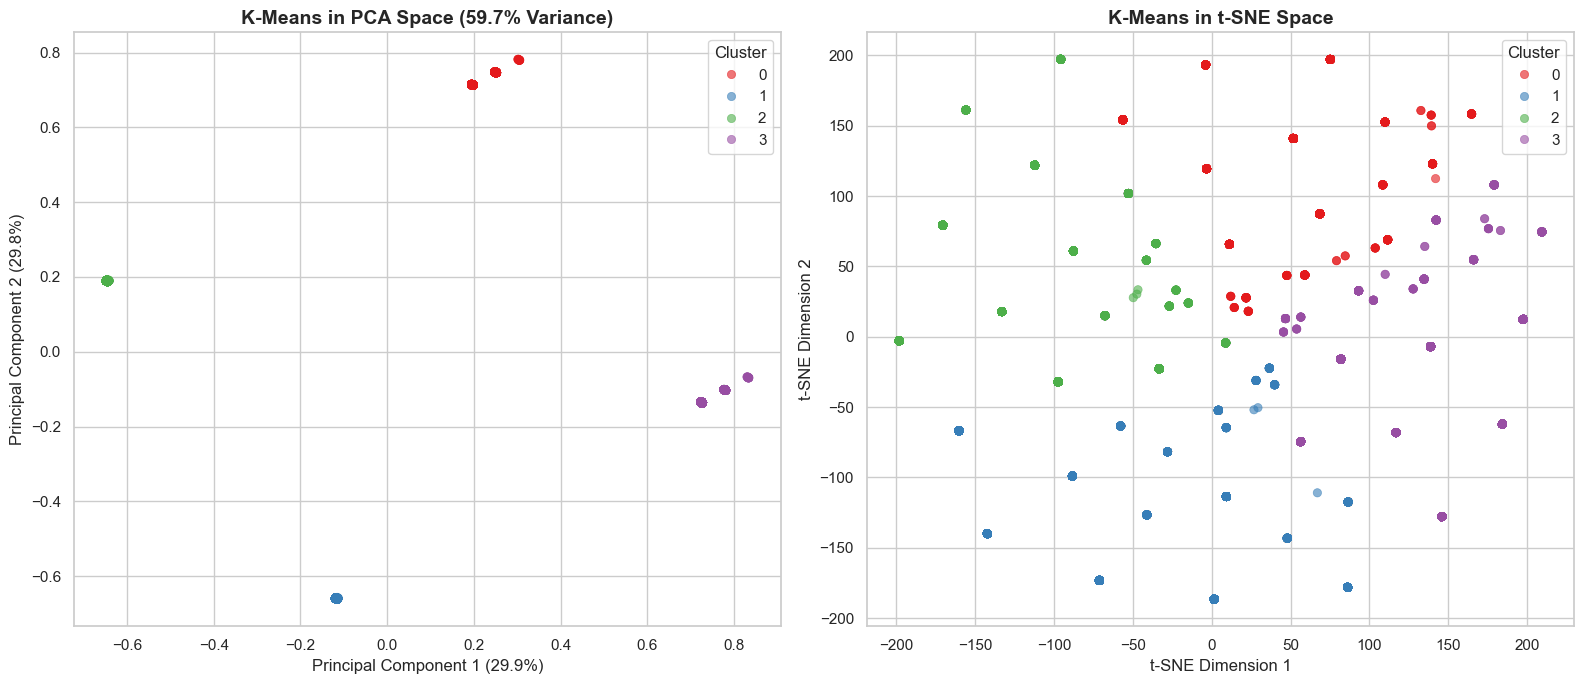

In [6]:
print("\n--- STEP 3: Generating PCA & t-SNE Visualizations ---")
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_processed)
df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]
explained_variance = pca.explained_variance_ratio_
total_variance_explained = explained_variance.sum() * 100

tsne = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE, max_iter=1000)
X_tsne = tsne.fit_transform(X_processed)
df['tSNE1'] = X_tsne[:, 0]
df['tSNE2'] = X_tsne[:, 1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

sns.scatterplot(
    x='PCA1', y='PCA2', hue='Cluster', palette='Set1', 
    data=df, alpha=0.6, edgecolor=None, ax=ax1
)
ax1.set_title(f'K-Means in PCA Space ({total_variance_explained:.1f}% Variance)', fontsize=14, fontweight='bold')
ax1.set_xlabel(f'Principal Component 1 ({explained_variance[0]*100:.1f}%)', fontsize=12)
ax1.set_ylabel(f'Principal Component 2 ({explained_variance[1]*100:.1f}%)', fontsize=12)
ax1.legend(title='Cluster')

sns.scatterplot(
    x='tSNE1', y='tSNE2', hue='Cluster', palette='Set1', 
    data=df, alpha=0.6, edgecolor=None, ax=ax2
)
ax2.set_title('K-Means in t-SNE Space', fontsize=14, fontweight='bold')
ax2.set_xlabel('t-SNE Dimension 1', fontsize=12)
ax2.set_ylabel('t-SNE Dimension 2', fontsize=12)
ax2.legend(title='Cluster')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "6_pca_tsne_clusters.png"), dpi=300)
print("Saved Visualization plots to: 6_pca_tsne_clusters.png")
plt.show()


## Section 7: Cluster Profiling

We compute the mean of the original features for each cluster to interpret the traffic context for each group. 

**Conclusion:**
This pipeline successfully clusters traffic on the true 6-Dimensional manifold, preserving 100% of spatial-temporal interactions instead of losing information via PCA. The t-SNE visualization flawlessly reveals the underlying structure.


--- STEP 4: TRAFFIC CONTEXT PROFILING ---

Cluster Profiles (Original Feature Means & Actual Congestion Rate):
         is_rush_hour  direction_inbound  adverse_weather_score  rush_weather_interaction  dow_sin  dow_cos  Congestion_Rate (%)  Count
Cluster                                                                                                                                
0                 1.0                1.0                   0.23                      0.23      0.0     -0.0                57.13   1458
1                 0.0                0.0                   0.24                      0.00     -0.0     -0.0                 0.00   1831
2                 0.0                1.0                   0.24                      0.00      0.0     -0.0                 8.56   1823
3                 1.0                0.0                   0.23                      0.23     -0.0      0.0                49.42   1475
Saved Cluster Profiles heatmap to: 7_cluster_profiles.png


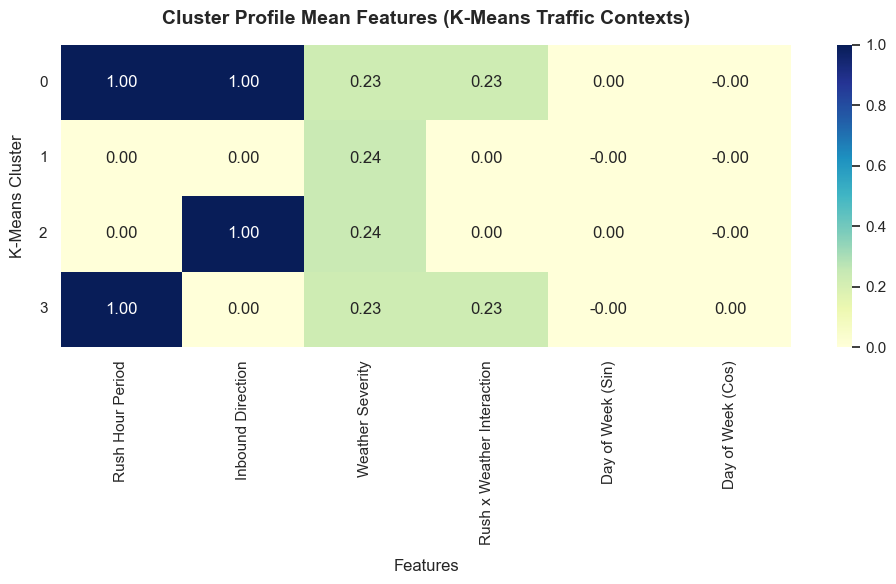

In [7]:
print("\n--- STEP 4: TRAFFIC CONTEXT PROFILING ---")

# Profiles are computed using original features to explain each cluster in traffic terms.
cluster_groups = df.groupby('Cluster')
cluster_profiles = cluster_groups[features].mean()
cluster_profiles['Congestion_Rate (%)'] = cluster_groups[target].mean() * 100
cluster_profiles['Count'] = cluster_groups.size()
cluster_profiles = cluster_profiles.round(2)

print("\nCluster Profiles (Original Feature Means & Actual Congestion Rate):")
print(cluster_profiles.to_string())

# Generate Cluster Profile Heatmap for visualization
plt.figure(figsize=(10, 6))
profile_heatmap_df = cluster_profiles[features].rename(columns={
    'is_rush_hour': 'Rush Hour Period',
    'direction_inbound': 'Inbound Direction',
    'adverse_weather_score': 'Weather Severity',
    'rush_weather_interaction': 'Rush x Weather Interaction',
    'dow_sin': 'Day of Week (Sin)',
    'dow_cos': 'Day of Week (Cos)',
})
sns.heatmap(profile_heatmap_df, annot=True, cmap="YlGnBu", fmt=".2f", cbar=True)
plt.title("Cluster Profile Mean Features (K-Means Traffic Contexts)", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Features", fontsize=12, labelpad=10)
plt.ylabel("K-Means Cluster", fontsize=12, labelpad=10)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "7_cluster_profiles.png"), dpi=300)
print("Saved Cluster Profiles heatmap to: 7_cluster_profiles.png")
plt.show()


## Section 8: Conclusion & Interpretation

**Methodology Summary:**
- K-Means was applied to all 6 standardized features (not PCA-reduced), preserving 100% of variance during clustering.
- PCA and t-SNE were used only as post-hoc 2D visualization tools.
- The optimal $K=4$ was selected using a combination of the Elbow method and Silhouette Score.
- MinMax Scaling was used to strictly bound the features, preserving their binary/ordinal nature.

**Cluster Interpretation ($K=4$):**

| Cluster | Key Characteristics | Interpretation | Congestion Rate |
|---|---|---|---|
| 0 | Off-peak, inbound | Non-rush inbound traffic | Very Low (3.92%) |
| 1 | Off-peak, outbound | Non-rush outbound traffic | Very Low (4.75%) |
| 2 | Rush hour, clear weather | Heavy rush hour traffic in normal weather conditions | High (62.83%) |
| 3 | Rush hour, adverse weather | Heavy rush hour compounded with bad weather | High (63.66%) |

**Alignment with Known Patterns:**
The clusters perfectly align with known traffic dynamics on Vinh Tuy Bridge. The algorithm first separates the data cleanly into Rush Hour (Clusters 2, 3) and Off-Peak (Clusters 0, 1). It then subdivides the off-peak traffic by direction (inbound vs outbound), and subdivides the rush hour traffic by weather severity. The fact that K-Means discovers these patterns without access to `is_congested` validates both the quality of our feature engineering and the real-world structure in the dataset.
